Consuming a Machine Learning Model

In [81]:
import os
import io
import cv2
import requests
import numpy as np
from IPython.display import Image, display

In [82]:
base_url = "http://127.0.0.1:8000"
endpoint = '/predict'
model = 'yolov3-tiny'

In [83]:
url_with_endpoint_no_params = base_url + endpoint
url_with_endpoint_no_params

'http://127.0.0.1:8000/predict'

In [84]:
full_url = url_with_endpoint_no_params + "?model=" + model
full_url

'http://127.0.0.1:8000/predict?model=yolov3-tiny'

Sending a request to your server

In [85]:
def response_from_server(url, image_file, verbose=True):

    files = {'file': image_file}
    response = requests.post(url, files=files)
    status_code = response.status_code
    if verbose:
        msg = "Everything went well!" if status_code == 200 else "There was an error when handling the request!"
        print(msg)
        print(f"Status code: {status_code}")
    return response

In [86]:
with open("images/car.jpg","rb") as image_file:
    prediction = response_from_server(full_url, image_file)

Everything went well!
Status code: 200


In [87]:
dir_name = "images_predicted"
if not os.path.exists(dir_name):
    os.mkdir(dir_name)

Creating the display_image_from_response function

In [88]:
def display_image_from_respose(response):

    image_stream = io.BytesIO(response.content)
    image_stream.seek(0)
    file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)                    # np.asarray() converts input data into a NumPy array.
    # bytearray(...) → turns it into a mutable byte sequence.
    # uint8 → Unsigned 8-bit integer
    # np.asarray(..., dtype=np.uint8) → NumPy array with values 0–255, ready for OpenCV
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    # cv2.imdecode is a OpenCV function that converts raw image bytes into an image matrix (NumPy array) that OpenCV can process.
    # cv2.IMREAD_COLOR --> Load color image (3 channels, BGR)
    filename = "image_with_objects.jpeg"
    cv2.imwrite(f'images_predicted/{filename}', image)
    display(Image(f'images_predicted/{filename}'))




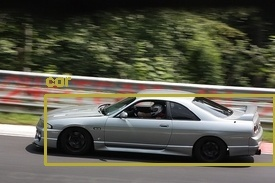

In [89]:
display_image_from_respose(prediction)

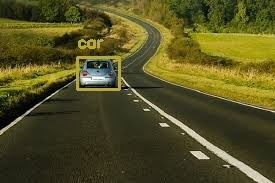

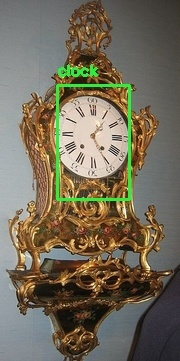

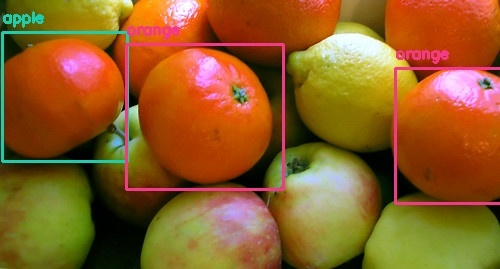

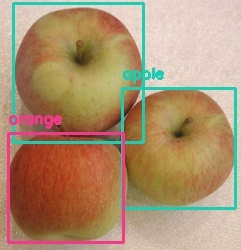

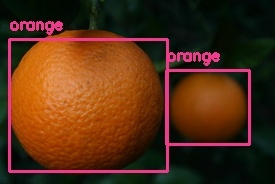

In [95]:
imagesList = ['car3.jpg','clock3.jpg','fruits.jpg','apples.jpg','oranges.jpg']

for img in imagesList:
    with open(f'images/{img}',"rb") as image_file:
        prediction = response_from_server(full_url, image_file, verbose=False)  # verbose=True → Print extra details (like progress, messages, warnings).

    display_image_from_respose(prediction)